# Experiment: PSO-SA Input Connectome Analysis


This notebook is intentionally thin. It rebuilds the input-side analyses from `_aPhN_DCSO_input_connectome_analysis_v1.ipynb` using shared package code instead of embedded workflow logic.


In [1]:
from pathlib import Path
import sys

from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise RuntimeError("Could not locate the standalone project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from giakoumas_connectome.data import discover_project_root, load_repository_tables
from giakoumas_connectome.inputs import build_direct_input_report, export_direct_input_report
from giakoumas_connectome.plots import (
    plot_direct_input_superclass_nerve,
    plot_direct_input_superclasses,
    save_figure,
)
from giakoumas_connectome.reports import build_workflow_report

import matplotlib.pyplot as plt


## Build The Shared Report


In [2]:
PROJECT_ROOT = discover_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / 'output' / 'pso_sa_input_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables = load_repository_tables(PROJECT_ROOT)
workflow_report = build_workflow_report('pso-sa', project_root=PROJECT_ROOT)
direct_input_report = build_direct_input_report(workflow_report, tables)
DISPLAY_LABELS = dict(zip(workflow_report.sets, workflow_report.workflow.set_labels, strict=True))

OUTPUT_DIR


PosixPath('/Users/dimitriosgiakoumas/Desktop/Giakoumas-et-al/giakoumas-connectome-python/output/pso_sa_input_analysis')

## Second-Order Input Fractions


In [3]:
summary = direct_input_report.second_order_input_percentage_summary.copy()
for column in [
    'mean_input_fraction_from_sets',
    'median_input_fraction_from_sets',
    'min_input_fraction_from_sets',
    'max_input_fraction_from_sets',
]:
    summary[column.replace('_fraction_', '_percent_')] = (summary[column] * 100).round(2)

display(
    summary[
        [
            'set_label',
            'second_order_neurons',
            'mean_input_percent_from_sets',
            'median_input_percent_from_sets',
            'min_input_percent_from_sets',
            'max_input_percent_from_sets',
        ]
    ]
)

for set_name, table in direct_input_report.second_order_input_percentages.items():
    print(DISPLAY_LABELS[set_name])
    display(table.sort_values('source_input_fraction', ascending=False).head())


,set_label,second_order_neurons,mean_input_percent_from_sets,median_input_percent_from_sets,min_input_percent_from_sets,max_input_percent_from_sets
0,DCSO,141,28.34,28.61,0.0,67.98
1,aPhN1,428,20.90,14.65,0.0,83.53
2,aPhN2,268,13.91,7.56,0.0,65.81


DCSO


,root_id,total_input_synapses,source_input_synapses,source_input_fraction
91,720575940629595633,178,121,0.679775
132,720575940640224640,234,154,0.658120
113,720575940632274914,305,192,0.629508
1,720575940605703456,177,108,0.610169
9,720575940610524339,259,158,0.610039


aPhN1


,root_id,total_input_synapses,source_input_synapses,source_input_fraction
172,720575940623029395,170,142,0.835294
107,720575940618691419,69,57,0.826087
232,720575940626065736,51,42,0.823529
87,720575940616777105,167,135,0.808383
361,720575940634702967,70,56,0.800000


aPhN2


,root_id,total_input_synapses,source_input_synapses,source_input_fraction
251,720575940640224640,234,154,0.658120
215,720575940632274914,305,192,0.629508
233,720575940635625367,385,233,0.605195
195,720575940630059052,320,193,0.603125
137,720575940625081290,601,351,0.584027


## Direct Inputs To The PSO-SA Sets


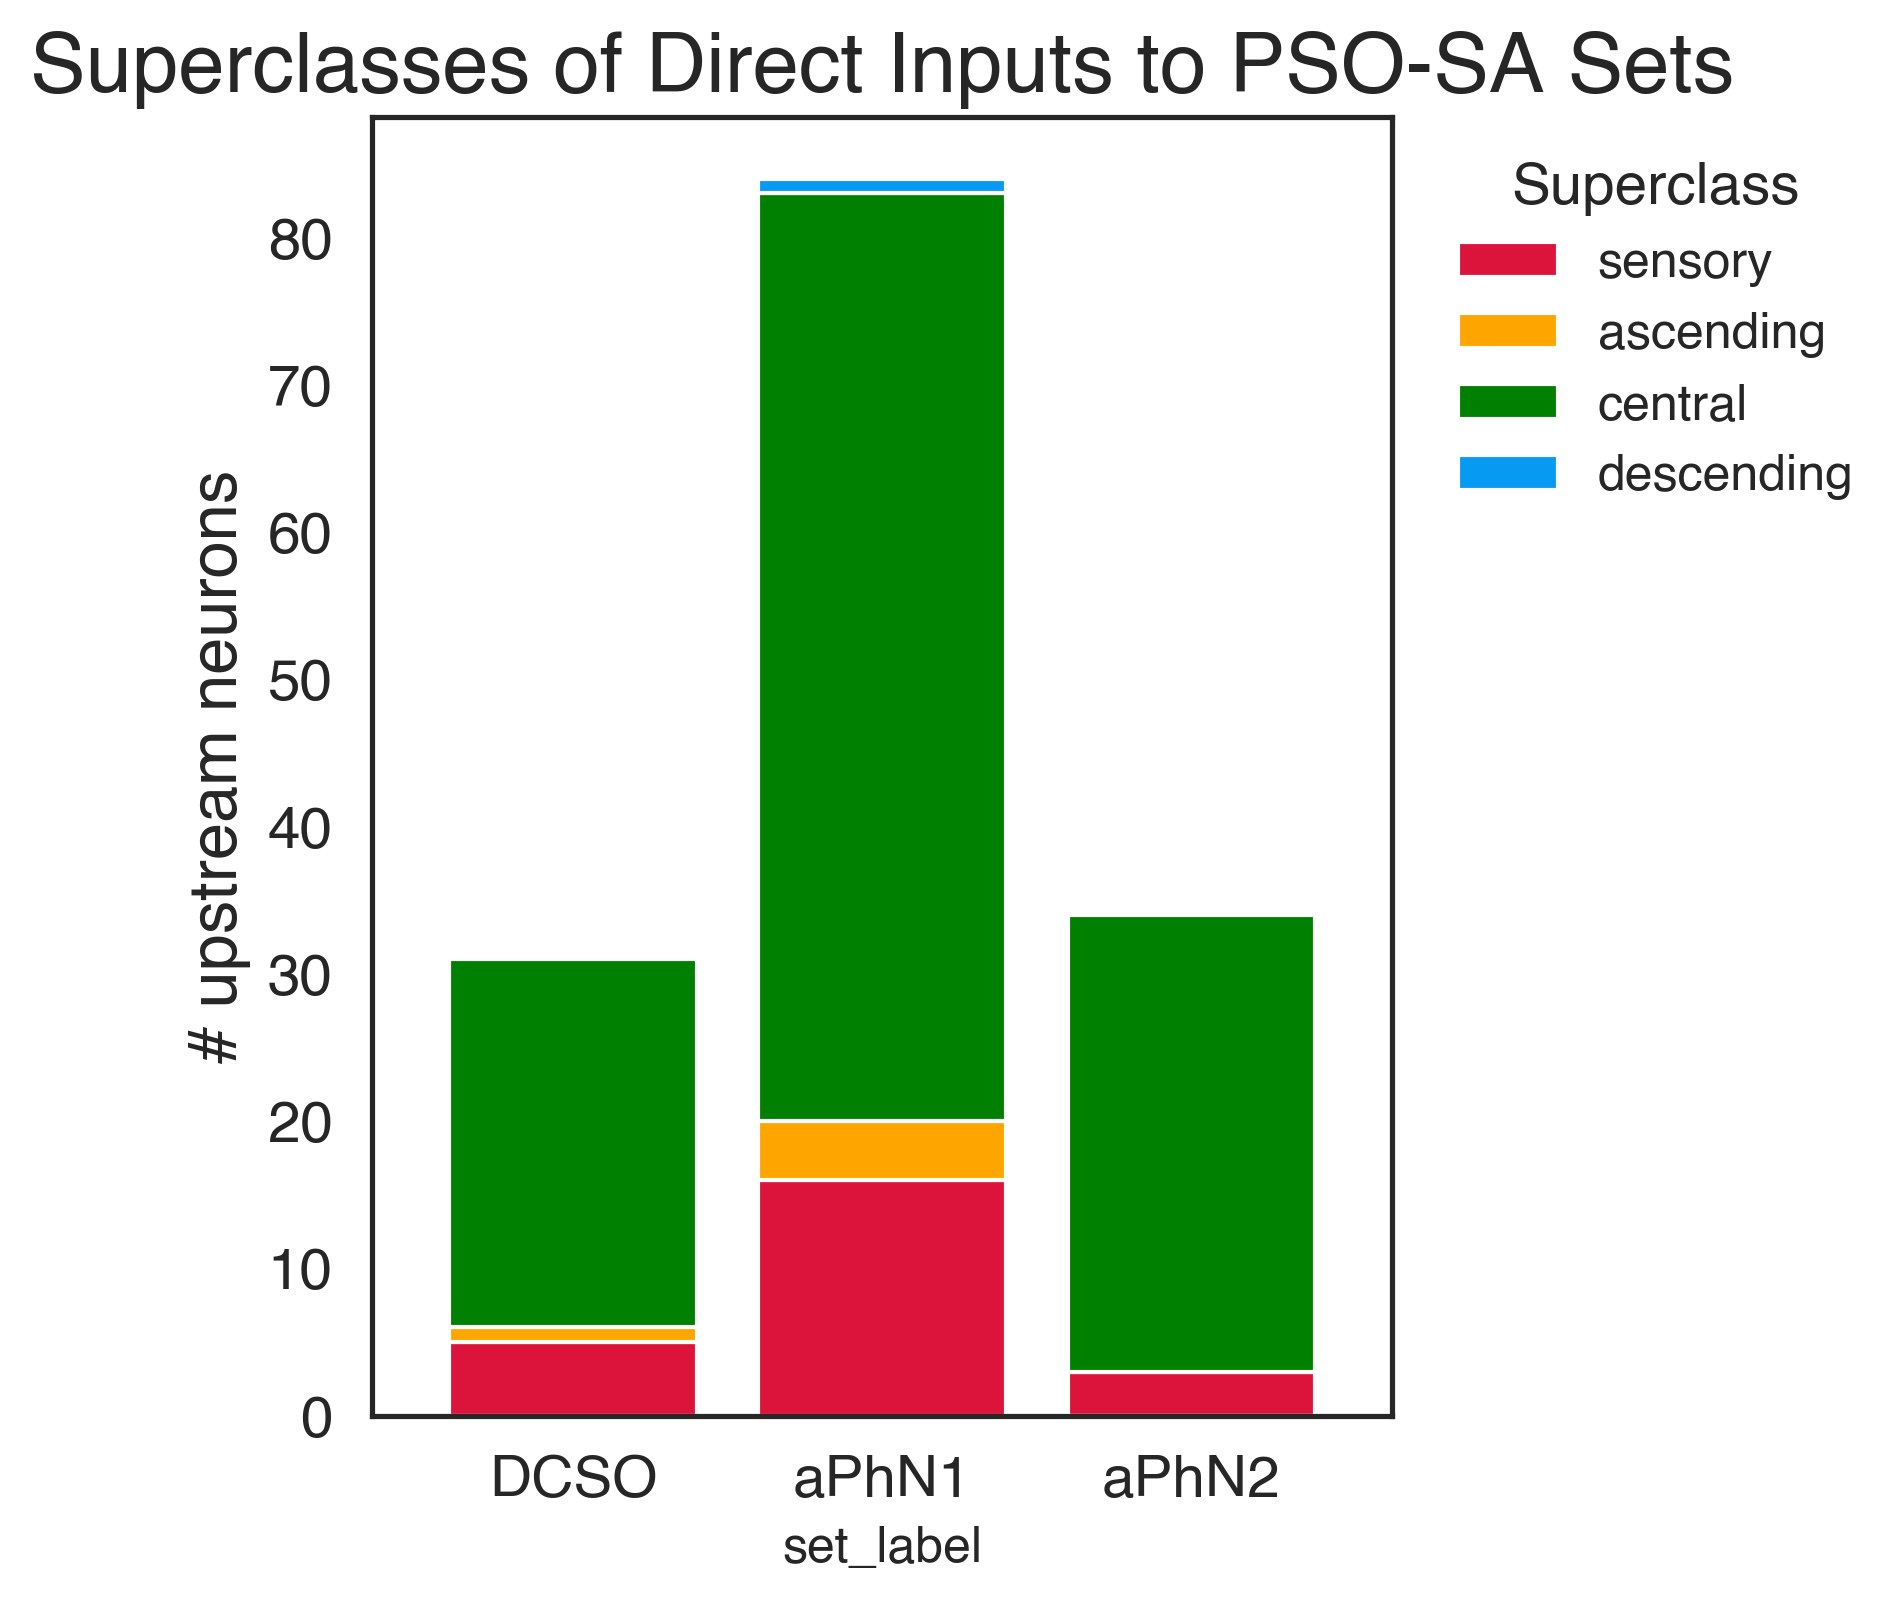

In [4]:
fig, _ = plot_direct_input_superclasses(
    direct_input_report.direct_input_superclass_counts,
    title='Superclasses of Direct Inputs to PSO-SA Sets',
)
plt.show()


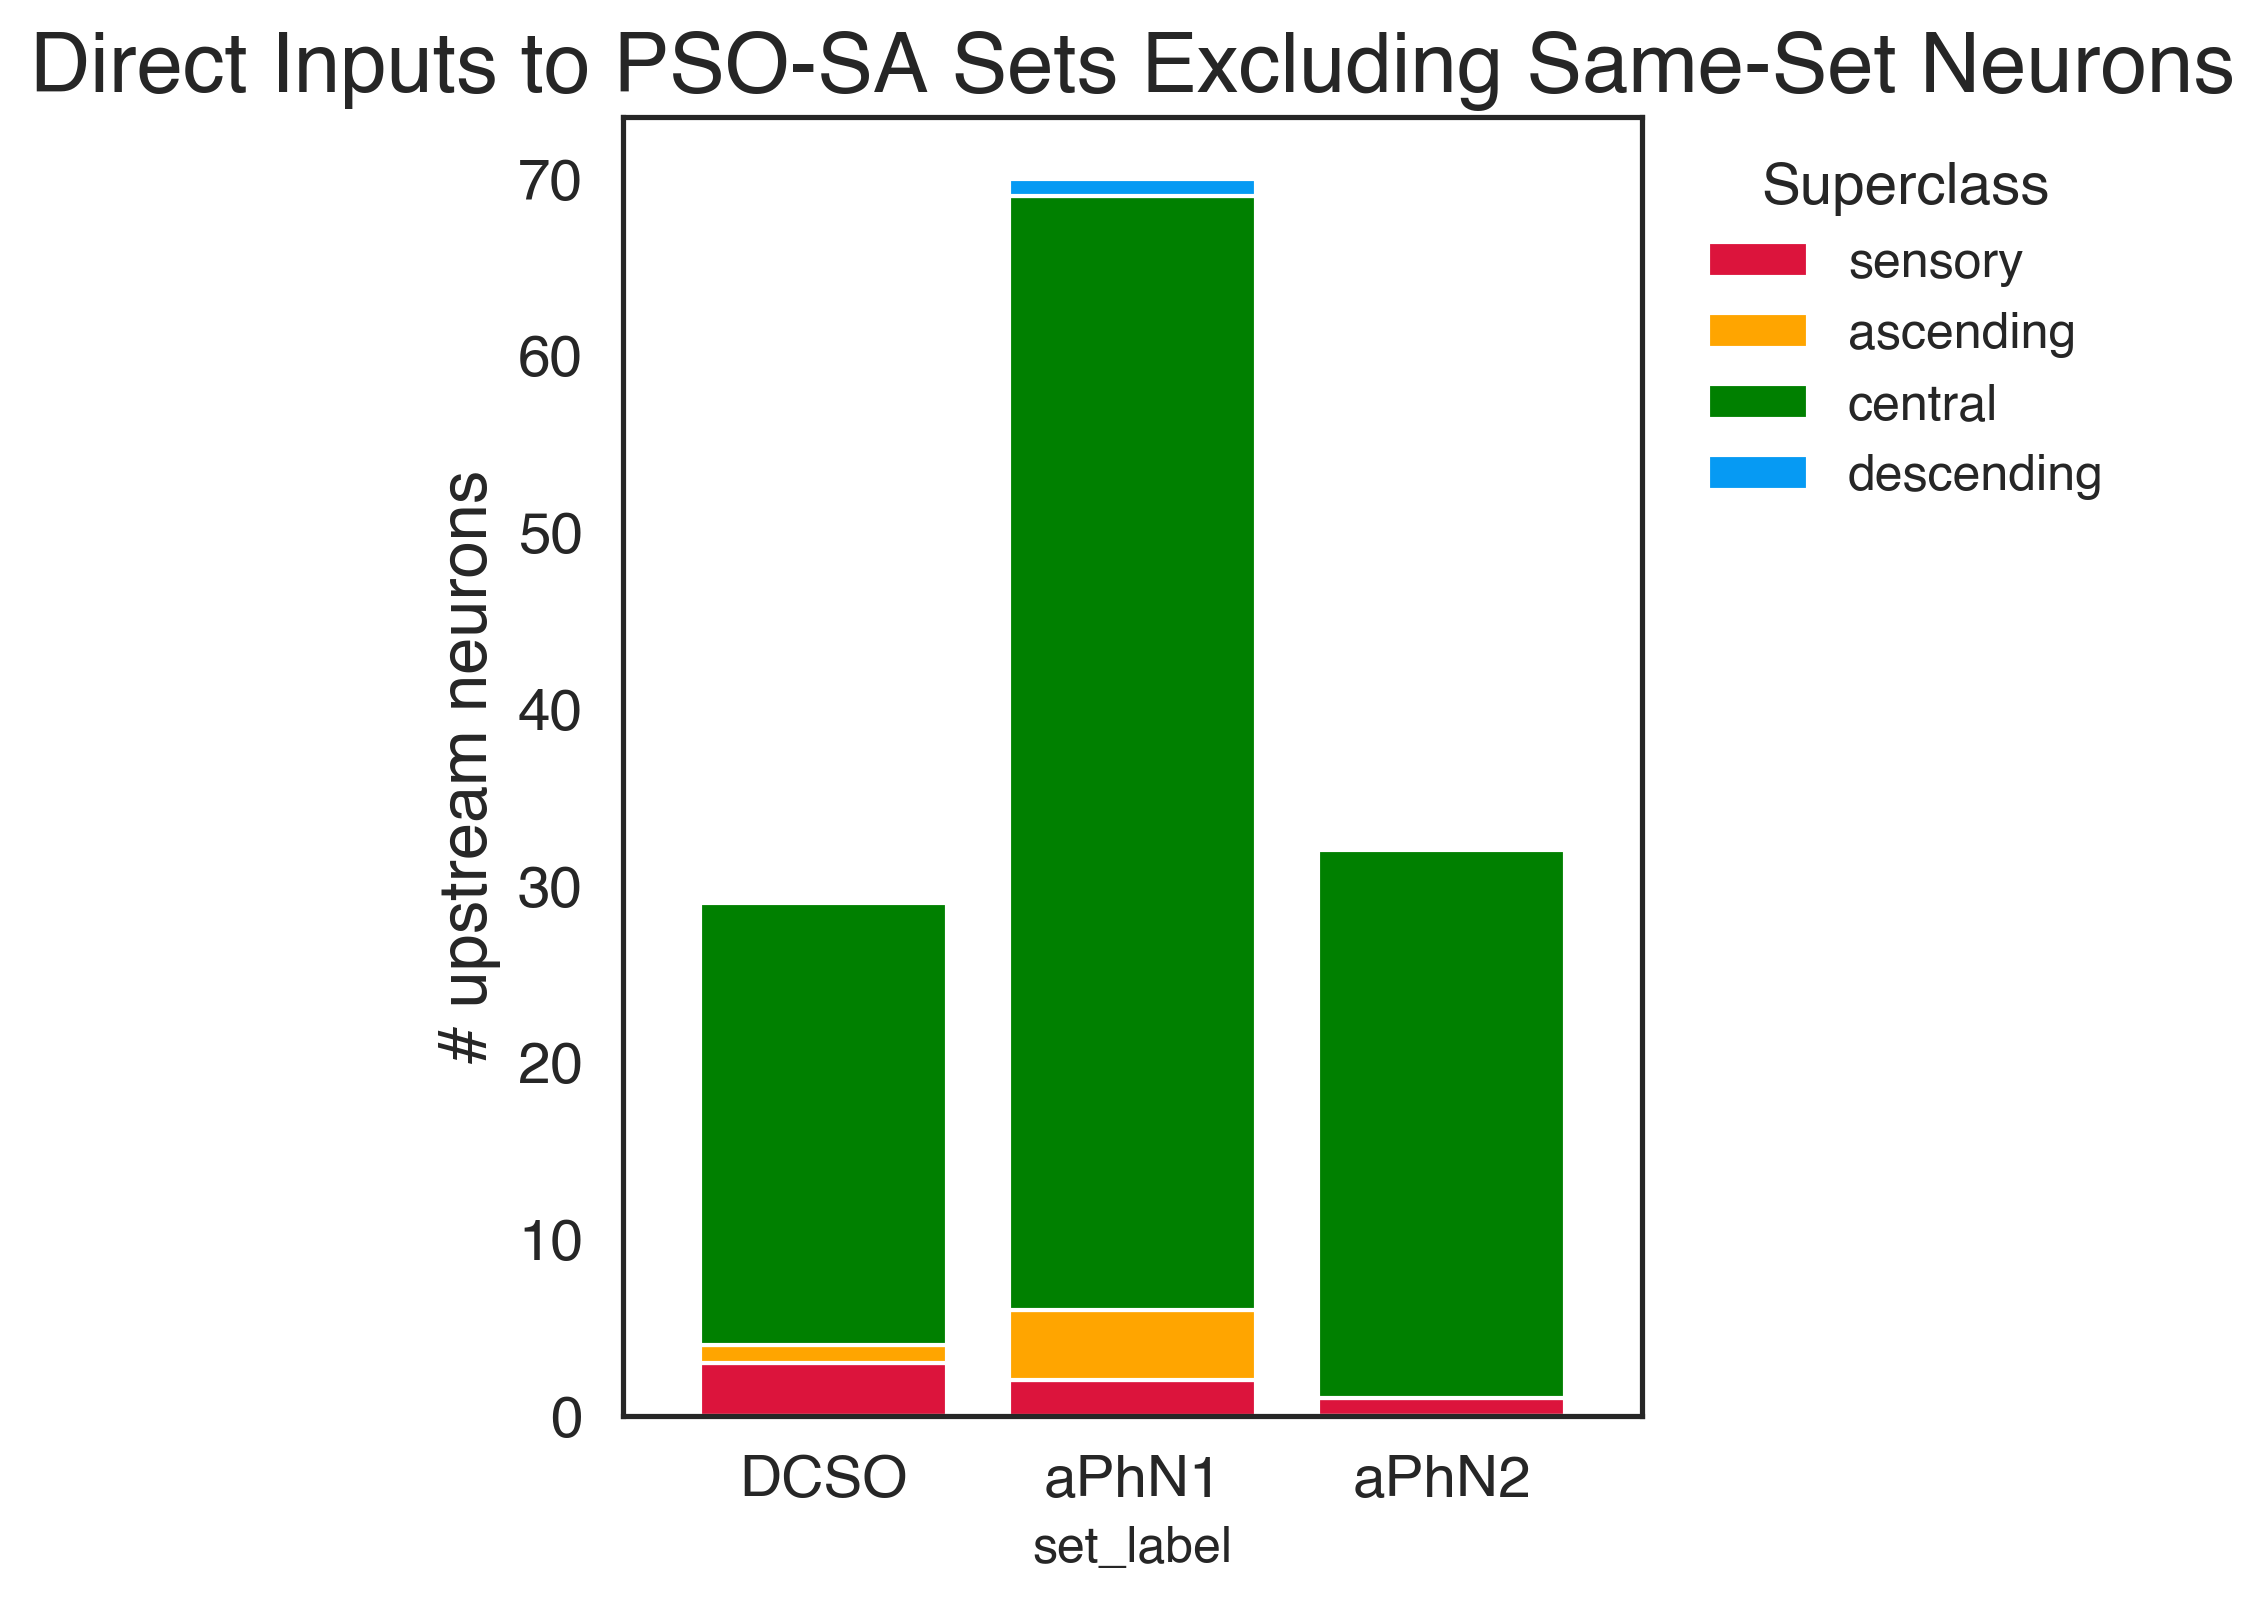

In [5]:
fig, _ = plot_direct_input_superclasses(
    direct_input_report.direct_input_superclass_counts_no_self,
    title='Direct Inputs to PSO-SA Sets Excluding Same-Set Neurons',
)
plt.show()


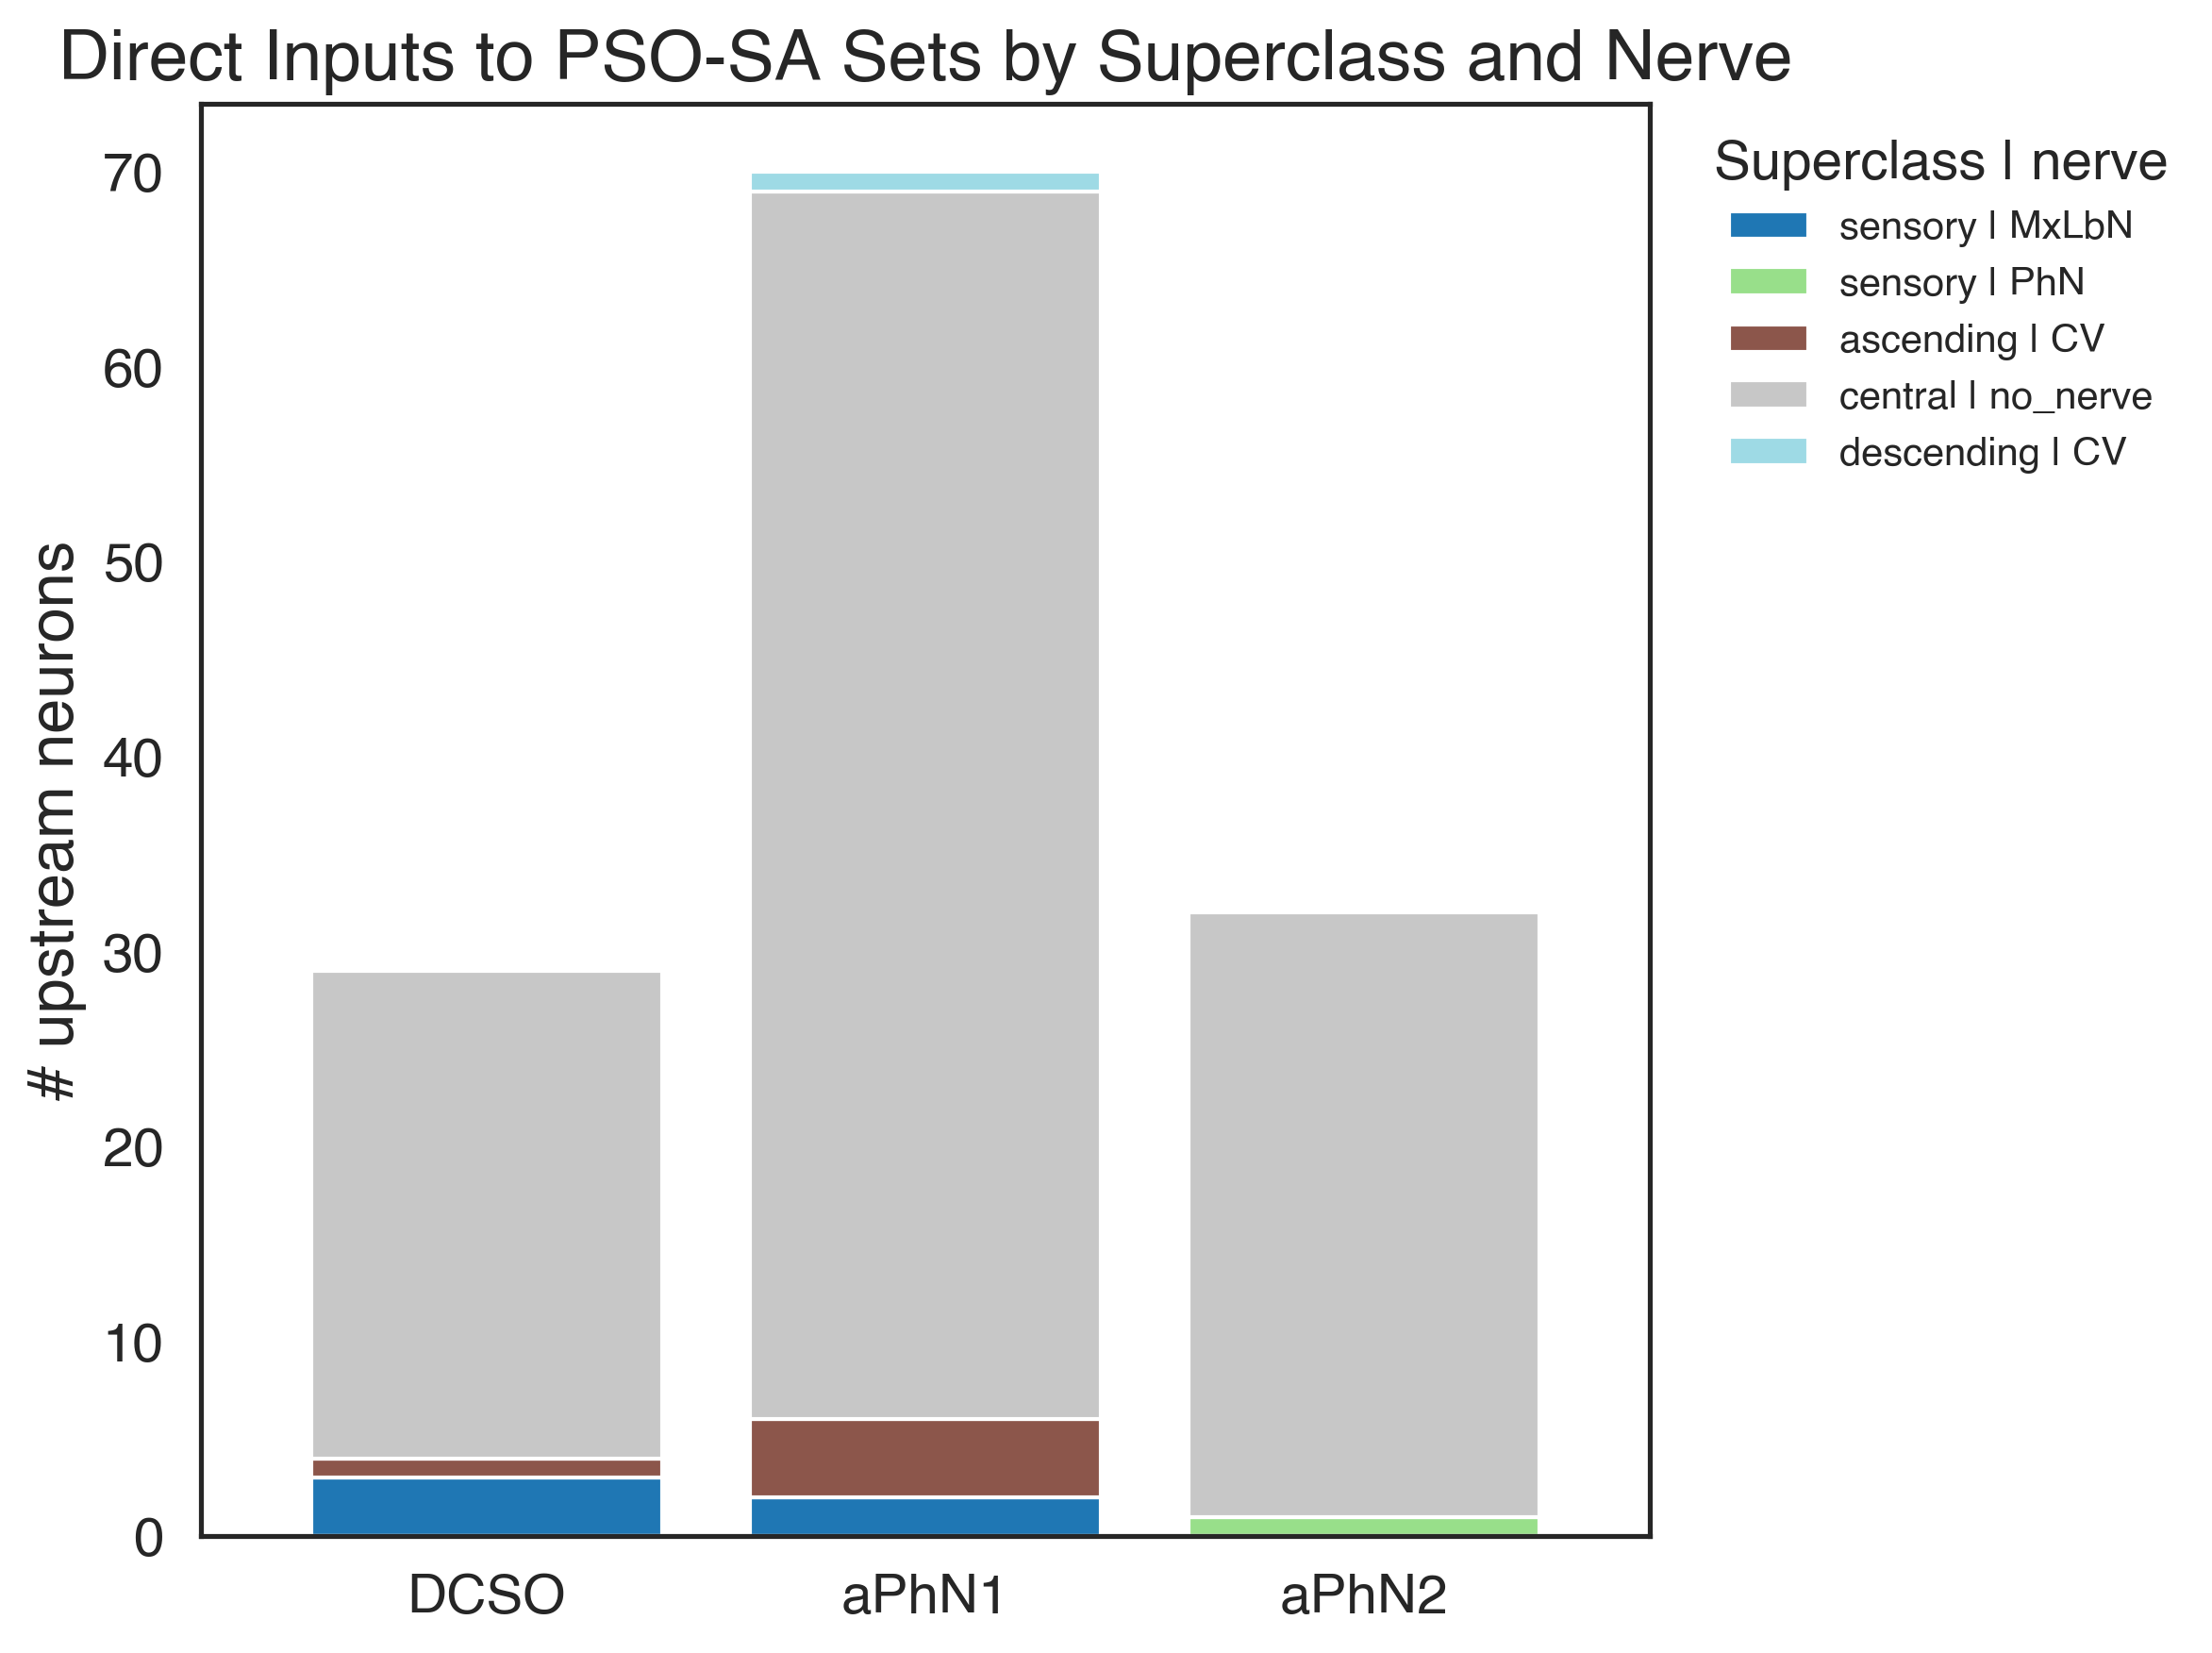

In [6]:
fig, _ = plot_direct_input_superclass_nerve(
    direct_input_report.direct_input_superclass_nerve_counts_no_self,
    title='Direct Inputs to PSO-SA Sets by Superclass and Nerve',
)
plt.show()


## Exported Outputs


In [7]:
table_paths = export_direct_input_report(direct_input_report, OUTPUT_DIR)
figure_dir = OUTPUT_DIR / 'figures'
figure_paths = {}

fig, _ = plot_direct_input_superclasses(
    direct_input_report.direct_input_superclass_counts,
    title='Superclasses of Direct Inputs to PSO-SA Sets',
)
figure_paths['direct_input_superclasses'] = save_figure(fig, figure_dir / 'direct_input_superclasses.svg')
plt.close(fig)

fig, _ = plot_direct_input_superclasses(
    direct_input_report.direct_input_superclass_counts_no_self,
    title='Direct Inputs to PSO-SA Sets Excluding Same-Set Neurons',
)
figure_paths['direct_input_superclasses_excluding_self'] = save_figure(
    fig,
    figure_dir / 'direct_input_superclasses_excluding_self.svg',
)
plt.close(fig)

fig, _ = plot_direct_input_superclass_nerve(
    direct_input_report.direct_input_superclass_nerve_counts_no_self,
    title='Direct Inputs to PSO-SA Sets by Superclass and Nerve',
)
figure_paths['direct_input_superclass_nerve_excluding_self'] = save_figure(
    fig,
    figure_dir / 'direct_input_superclass_nerve_excluding_self.svg',
)
plt.close(fig)

sorted(
    str(path.relative_to(PROJECT_ROOT))
    for path in [*table_paths.values(), *figure_paths.values()]
)


['output/pso_sa_input_analysis/figures/direct_input_superclass_nerve_excluding_self.svg',
 'output/pso_sa_input_analysis/figures/direct_input_superclasses.svg',
 'output/pso_sa_input_analysis/figures/direct_input_superclasses_excluding_self.svg',
 'output/pso_sa_input_analysis/tables/direct_input_superclass_counts.csv',
 'output/pso_sa_input_analysis/tables/direct_input_superclass_counts_excluding_self.csv',
 'output/pso_sa_input_analysis/tables/direct_input_superclass_nerve_counts_excluding_self.csv',
 'output/pso_sa_input_analysis/tables/second_order_input_percentage_summary.csv',
 'output/pso_sa_input_analysis/tables/set_1/set_1_direct_inputs.csv',
 'output/pso_sa_input_analysis/tables/set_1/set_1_direct_inputs_excluding_self.csv',
 'output/pso_sa_input_analysis/tables/set_1/set_1_direct_inputs_superclass_nerve_excluding_self.csv',
 'output/pso_sa_input_analysis/tables/set_1/set_1_second_order_input_percentages.csv',
 'output/pso_sa_input_analysis/tables/set_2/set_2_direct_inputs.cs